# Right-Turning Vehicle Crash Severity Analysis 
## Milestone 2: Initial prototype and workflow

This notebook shows the initial workflow for analyzing how different road geometric configurations and traffic characteristics affect crash severity for right-turning vehicles at intersections. 

The initial workflow will: 
1. Load a CSV database that contains the variables regarding roadway geometric and traffic characteristics of intersections and crash severity outcomes involving right-turning vehicles at intersections, and check its structure, variables, and missing values. 
2. Create a bar chart showing how many right-turning crashes fall into each crash severity category.
3. Show the variable categories for "speed limit" of roadways.
4. Create a bar chart showing the crash severity outcomes by roadway speed limit.


In [1]:
import pandas as pd

df = pd.read_csv("../data/right_turn_crashes.csv")

df.head()

df.shape

df.info()

df.columns.tolist()

df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1683 entries, 0 to 1682
Columns: 174 entries, OBJECTID to CrashSeverity
dtypes: float64(73), object(101)
memory usage: 2.2+ MB


OBJECTID                2
Join_Count              2
TARGET_FID              2
Join_Count_1            2
TARGET_FID_1            2
                       ..
Weather.1               2
PedestrianInvolved.1    2
NumVehicles.1           2
DriverLevelFactors      2
CrashSeverity           2
Length: 174, dtype: int64

In [2]:
df["CrashSeverity"].value_counts()

CrashSeverity
Injury       913
No injury    768
Name: count, dtype: int64

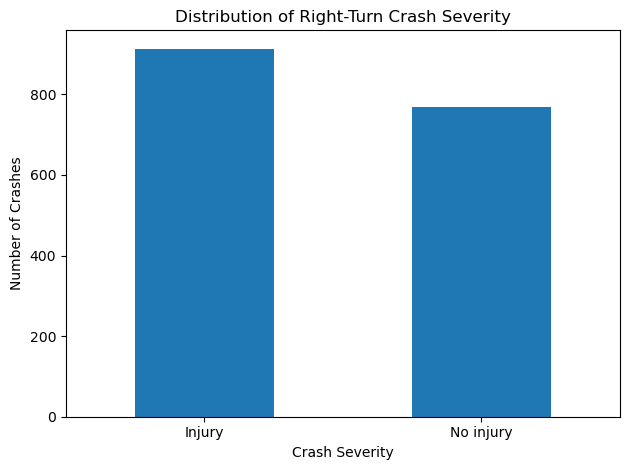

In [4]:
import matplotlib.pyplot as plt

df["CrashSeverity"].value_counts().plot(kind="bar")

plt.xlabel("Crash Severity")
plt.ylabel("Number of Crashes")
plt.title("Distribution of Right-Turn Crash Severity")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [7]:
df["SpeedLimit"].describe()

SpeedLimit
30 or 35 mph      664
40 mph or more    604
25 mph or less    413
Name: count, dtype: int64

In [8]:
df["SpeedLimit"].value_counts()

SpeedLimit
30 or 35 mph      664
40 mph or more    604
25 mph or less    413
Name: count, dtype: int64

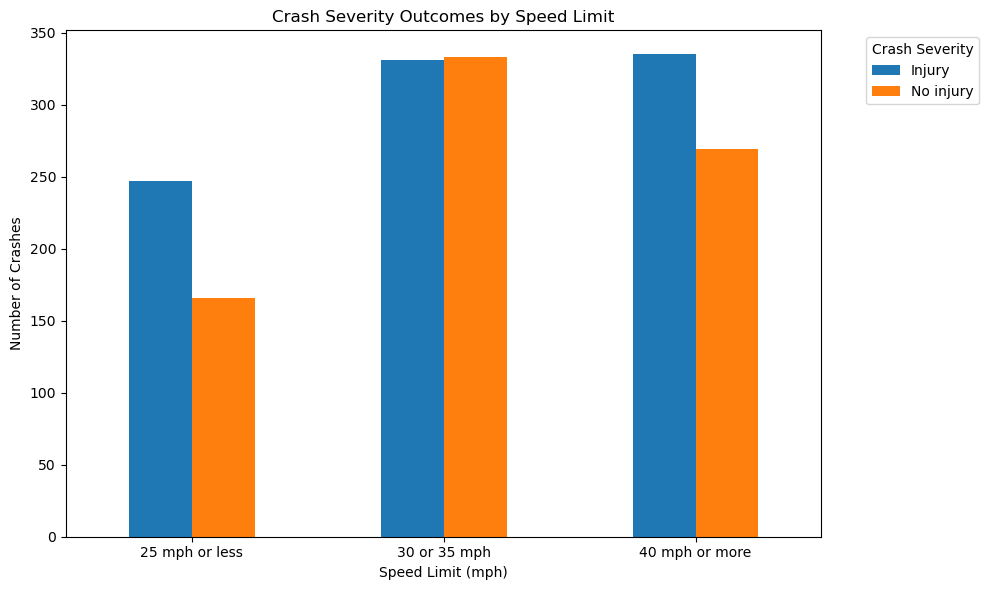

In [9]:
import matplotlib.pyplot as plt

# Count crashes by speed limit and crash severity
severity_by_speed = (
    df.groupby(["SpeedLimit", "CrashSeverity"])
      .size()
      .unstack(fill_value=0)
)

# Create grouped bar chart
severity_by_speed.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.xlabel("Speed Limit (mph)")
plt.ylabel("Number of Crashes")
plt.title("Crash Severity Outcomes by Speed Limit")

plt.xticks(rotation=0)

plt.legend(
    title="Crash Severity",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

## Limitation:
This prototype is only to verify workflow. Additional variable recoding and model specification will be completed in later project milestones. 